In [149]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [150]:
df = pd.read_csv('covid_toy.csv' , usecols=['fever', 'age' , 'has_covid'])

In [151]:
df.sample(5)

,age,fever,has_covid
11,65,98.0,Yes
97,20,101.0,No
1,27,100.0,Yes
66,51,104.0,No
19,42,NaN,Yes


In [152]:
df.isnull().sum()

,0
age,0
fever,10
has_covid,0


In [153]:
df.fillna(df['age'].mean(), inplace=True)

In [154]:
x = df.iloc[: , :2]
y = df.iloc[ : , -1]

In [155]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=2)

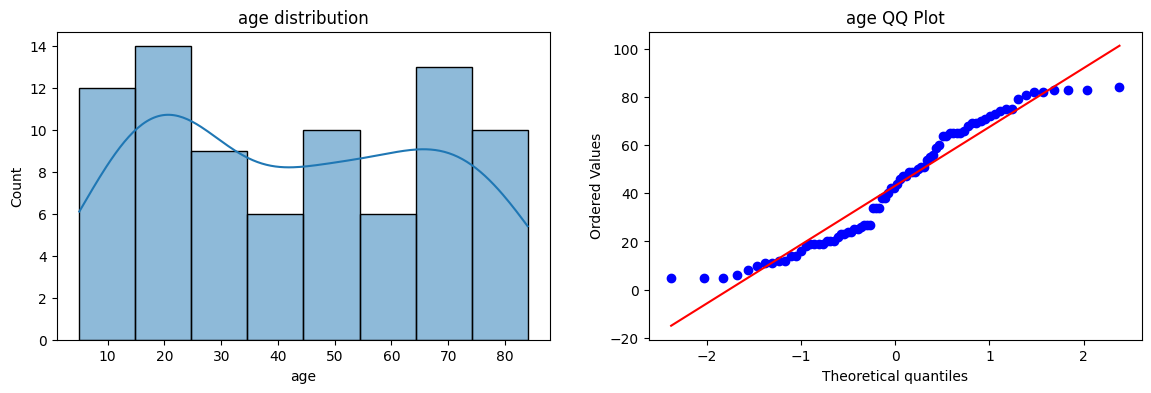

In [156]:
plt.figure(figsize =(14,4))
plt.subplot(121)
sns.histplot(x_train['age'] , kde=True)
plt.title('age distribution')


plt.subplot(122)
stats.probplot(x_train['age'] , dist="norm" , plot=plt)
plt.title('age QQ Plot')
plt.show()

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [113]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [114]:
clf1.fit(x_train , y_train)
clf2.fit(x_train , y_train)

y_pred = clf1.predict(x_test)
y_pred2 = clf2.predict(x_test)

In [115]:
accuracy_score(y_test , y_pred)

0.55

In [116]:
accuracy_score(y_test , y_pred2)
#

0.4

In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [139]:
trf1 = FunctionTransformer(func=np.reciprocal)   #note np.log1p works better for this dataset

In [140]:
x_train_transform1 = trf1.fit_transform(x_train)
x_test_tranform1 = trf1.transform(x_test)

In [141]:
clftt = LogisticRegression()
clftt2 = DecisionTreeClassifier()

In [142]:
clftt.fit(x_train , y_train)
clftt2.fit(x_train , y_train)

y_predtt = clftt.predict(x_test)
y_predtt2 = clftt2.predict(x_test)

In [143]:

accuracy_score(y_test , y_predtt)

0.55

In [144]:
accuracy_score(y_test , y_predtt2)

0.4

In [145]:
from sklearn.model_selection import cross_val_score

In [146]:
x_transform = trf1.fit_transform(x)

clfLL = LogisticRegression()
clfDD = DecisionTreeClassifier()

score = np.mean(cross_val_score(clfLL , x_transform , y ,scoring='accuracy' , cv=10))
score2 =np.mean(cross_val_score(clfDD , x_transform , y , scoring="accuracy" , cv=10))

In [147]:
print(score , score2)


0.55 0.62


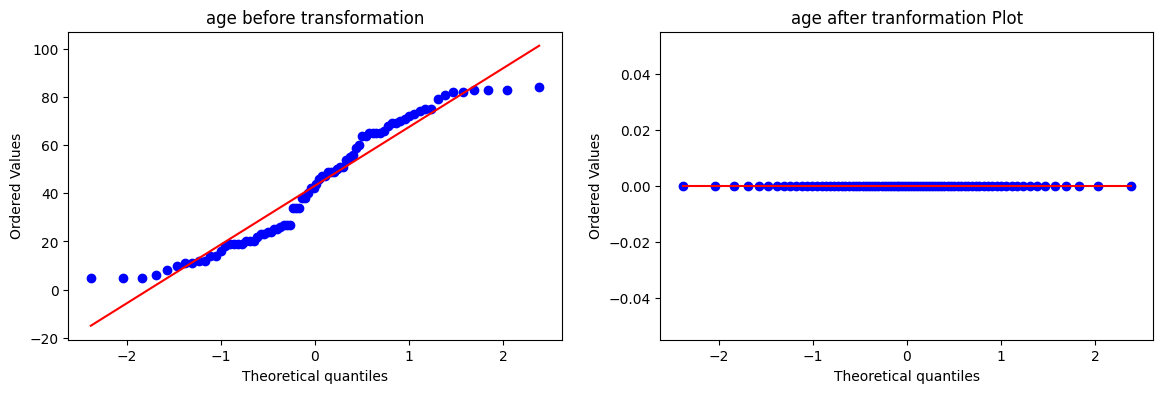

In [148]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['age'] ,dist= "norm" , plot=plt)
plt.title("age before transformation")


plt.subplot(122)
stats.probplot(x_train_transform1['age'] , dist="norm" , plot=plt)
plt.title('age after tranformation Plot')
plt.show()
